# dmf research walkthrough — from raw disputes to a selected model

This notebook runs the **`dmf.research` selection harness end-to-end** on small synthetic
dispute data (~90 seconds total), and shows how to read each output — because each step's
output is the *input* to the next:

```
config  →  variable ordering  →  model × k grid  →  marginal gains  →  1-SE selection  →  holdout confirmation
(the experiment)  (which subsets exist)  (how good is each)  (does var k earn its place?)  (which spec ships)  (the honest number)
```

Run it from the `examples/` folder, top to bottom. Every cell is short on purpose.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dmf import Config, ProductionScorer
from dmf.research import ModelSelectionHarness
from generate_synthetic_disputes import generate_disputes   # lives beside this notebook

# fixed identity colors: one per model, used consistently in every chart below
C = {"logistic": "#3b6fd4", "gbm": "#c8571b"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True})

df = generate_disputes(n=4000, seed=11, prevalence=0.10)
print(f"{df.shape[0]:,} disputes, {df.shape[1]-2} candidate columns, "
      f"prevalence {df['is_fraudulent_dispute'].mean():.1%}")
df.head(3)

4,000 disputes, 33 candidate columns, prevalence 10.0%


,dispute_id,dispute_amount,txn_amount,amount_to_daily_spend_ratio,days_txn_to_dispute,cardholder_tenure_months,cardholder_tenure_years,prior_disputes_12m,prior_disputes_lifetime,prior_dispute_upheld_ratio,...,noise_gamma,merchant_id,merchant_category,channel,claim_channel,device_type,region,customer_segment,dispute_reason_code,is_fraudulent_dispute
0,D2026000000,32.82,37.18,0.2410,6.7,42.1,3.481,0,0,0.7252,...,7.1907,M100001,apparel,card_present,web_portal,android,southeast,mass,10.4_other_fraud,0
1,D2026000001,20.32,21.32,0.5684,5.0,90.0,7.507,1,1,0.7586,...,1.7384,M100131,pharmacy,atm,mobile_app,ios,southeast,mass,13.6_credit_not_processed,0
2,D2026000002,99.98,112.22,3.9906,6.3,32.7,2.782,0,0,0.5986,...,1.3534,M100200,travel,mobile_wallet,web_portal,ios,northeast,affluent,12.5_incorrect_amount,0


## Step 1 — the config *is* the experiment

Everything the harness does is declared here: which models compete, how many variables to
sweep (`k_min..k_max`), the split design, the metric, and which segments to audit on the
holdout. Nothing downstream takes arguments — change the experiment by changing this.

We keep it deliberately small: **2 models × k=1..6 × 3-fold CV**, so a human can watch it run.

In [2]:
cfg = Config.from_dict({
    "run": {"name": "walkthrough", "output_dir": "./artifacts_demo", "random_state": 7,
            "n_jobs": 1, "verbose": 0, "save_fitted_model": False},
    "data": {"target": "is_fraudulent_dispute"},
    "columns": {"auto_infer": True, "drop": ["dispute_id", "merchant_id"]},
    "split": {"holdout_size": 0.25, "cv": {"n_splits": 3}},
    "selection": {"k_min": 1, "k_max": 6, "top_n": 3},
    "metrics": {"primary": "average_precision",
                "secondary": ["roc_auc", "ks_statistic", "brier_score"],
                "slice_columns": ["customer_segment", "claim_channel"], "min_slice_n": 40},
    "models": {
        "logistic": {"estimator": "sklearn.linear_model.LogisticRegression", "tag": "champion",
                     "family": "linear", "requires_scaling": True, "imbalance": "balanced",
                     "params": {"C": 1.0, "max_iter": 1000}},
        "gbm": {"estimator": "sklearn.ensemble.HistGradientBoostingClassifier", "tag": "challenger",
                "family": "tree", "requires_scaling": False, "imbalance": "balanced",
                "params": {"max_iter": 120, "learning_rate": 0.08, "early_stopping": False}},
    },
})
print("models:", list(cfg.enabled_models), "| primary metric:", cfg.metrics.primary,
      "| k sweep: 1..", cfg.selection.k_max)

models: ['logistic', 'gbm'] | primary metric: average_precision | k sweep: 1.. 6


## Step 2 — run the harness once

One call does the whole sequence. Internally, per CV fold it: types the columns → ranks the
variables *inside that fold* (so no validation row helps choose the features it scores) →
fits every model at every k → scores the fold. Then it aggregates, tests marginal gains,
applies the 1-SE rule, and confirms the winner on the untouched 25% holdout.

The step log below is the run's audit trail — one line of numbers per step. Skim it now;
we unpack each step next.

In [3]:
result = ModelSelectionHarness(cfg).run(df.copy())
print(result.report.render(max_width=130))

=== step report: walkthrough ===
[lineage] python=3.12.10  platform=Windows-11-10.0.26200-SP0  config_sha256=7c772a04c15ad5d1  data_rows=4000  data_columns=32  ...
[data_load] name=features  n_rows=4000  n_columns=32  total_missing_rate=0.005188  duplicate_row_rate=0.0
[data_target] name=target  n_rows=4000  n_positive=400  n_negative=3600  prevalence=0.1  imbalance_ratio=9.0  positive_label=1 ...
[data_quality] n_dropped_columns=2  duplicate_row_rate=0.0  duplicate_rows_material=False  total_missing_rate=0.005188
[holdout_split] strategy=random  holdout_size=0.25  stratified=True  n_train=3000  n_holdout=1000  train_prevalence=0.1  holdou...
[candidate_variables] n_candidates=32  source=auto_inferred  n_numeric=20  n_categorical=12  n_passthrough=0  n_dropped=0
[estimator_zoo] n_models=2  n_skipped=0
[variable_ordering] mode=per_model  strategy=importance  n_candidates=32  mean_rank_correlation=-0.0946  top1_agreement=0.5  to...
[selection_stability] n_folds=3  k_cap=6
[cv_grid] n_var

## Step 3 — variable ordering & stability

**What it is:** inside each fold, each model ranks all candidate variables; the top-k prefix
of that ranking defines which variable subsets the grid evaluates. **Why it matters
downstream:** the grid can only score subsets the ordering proposes — an unstable ordering
means the "k=4 model" is a different 4 variables in every fold.

**How to read it:** the chart shows the share of folds in which each variable survived into
the top-k. Bars at 1.0 = the backbone of the model, selected every time. Bars near 0.3 =
fold-dependent noise — be suspicious if one of these ends up in the final spec.

selected in every fold: {'logistic': ['merchant_category', 'prior_disputes_12m', 'spend_decile'], 'gbm': ['amount_to_daily_spend_ratio', 'days_txn_to_dispute', 'prior_disputes_12m']}


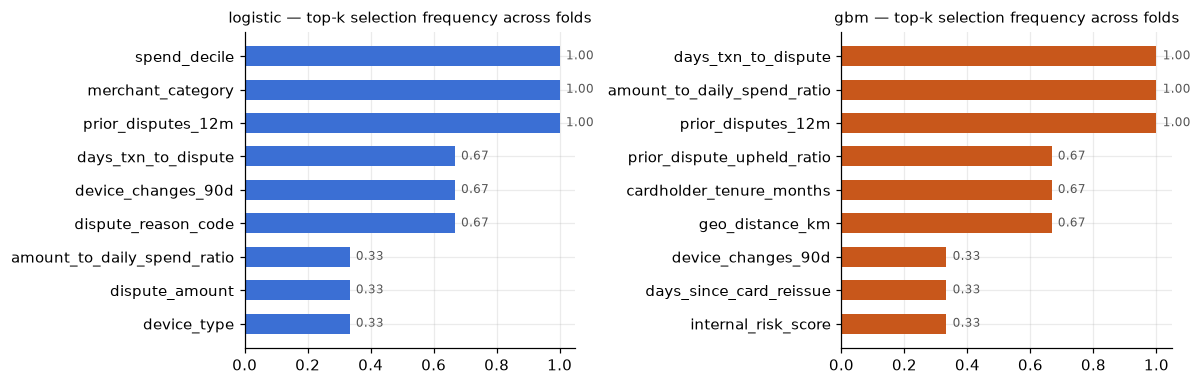

In [4]:
stab = result.report.get("selection_stability")["selection_frequency"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
for ax, (model, freqs) in zip(axes, stab.items()):
    s = pd.Series(freqs).sort_values()
    ax.barh(s.index, s.values, color=C[model], height=0.6)
    ax.set_title(f"{model} — top-k selection frequency across folds", fontsize=10)
    ax.set_xlim(0, 1.05)
    for y, v in enumerate(s.values):
        ax.text(v + 0.02, y, f"{v:.2f}", va="center", fontsize=8, color="#555")
plt.tight_layout()
always = result.report.get("selection_stability")["always_selected"]
print("selected in every fold:", always)

## Step 4 — the leaderboard: performance vs number of variables

**What it is:** every (model × k) cell scored by fold-nested CV. **How to read it:** each
curve is one model; the error bars are the **Nadeau–Bengio corrected** standard error
(folds share training data, so the naive SE would be ~⅓ too narrow). Look for where each
curve *plateaus* — variables past the bend are candidates for cutting, which is exactly
what the next two steps decide formally.

This table is the input to both the marginal-gain tests and the 1-SE selection.

,rank,model,k,cv_average_precision_mean,cv_average_precision_se,overfit_gap
0,1,logistic,6,0.329644,0.051956,0.063728
1,2,logistic,4,0.325843,0.052275,0.046120
2,3,logistic,2,0.322083,0.024927,0.013632
3,4,logistic,5,0.320479,0.052945,0.063932
4,5,logistic,3,0.319443,0.035100,0.030795
5,6,gbm,6,0.300514,0.030164,0.699327


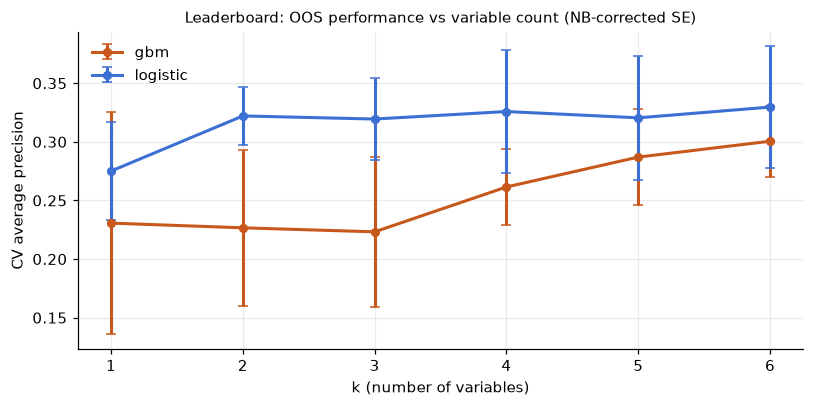

In [5]:
lb = result.leaderboard
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for model, g in lb.groupby("model"):
    g = g.sort_values("k")
    ax.errorbar(g["k"], g["cv_average_precision_mean"], yerr=g["cv_average_precision_se"],
                color=C[model], marker="o", ms=5, lw=2, capsize=3, label=model)
ax.set_xlabel("k (number of variables)"); ax.set_ylabel("CV average precision")
ax.set_title("Leaderboard: OOS performance vs variable count (NB-corrected SE)", fontsize=10)
ax.legend(frameon=False)
plt.tight_layout()
lb[["rank", "model", "k", "cv_average_precision_mean", "cv_average_precision_se",
    "overfit_gap"]].head(6)

**Also check `overfit_gap`** (train − OOS score): a cell with strong CV performance *and* a
large gap is memorising — the selection rule below only sees the OOS number, so the gap is
your independent sanity check on any spec you're about to trust.

## Step 5 — marginal gains: does the k-th variable earn its place?

**What it is:** for the best model, the paired fold-level change in AP going from k−1 → k
variables, with a Nadeau–Bengio corrected t-test. **How to read it:** solid bars are
statistically significant improvements; faded bars are noise. This is the plateau from
Step 4 made precise — and it's the evidence the 1-SE rule (next) uses implicitly: once
gains stop being significant, extra variables are cost without benefit.

,from_k,to_k,added_variable,mean_delta,p_value,verdict
0,1,2,spend_decile,0.047043,0.120269,not_significant
1,2,3,merchant_category,-0.002640,0.890037,not_significant
2,3,4,dispute_reason_code,0.006401,0.746573,not_significant
3,4,5,days_txn_to_dispute,-0.005364,0.016129,degrades
4,5,6,device_changes_90d,0.009166,0.530459,not_significant


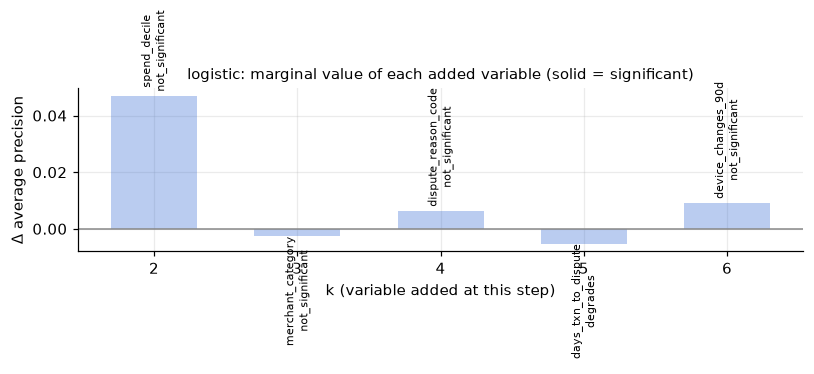

In [6]:
best_model = result.selected["model"]
g = result.marginal_gains.query("model == @best_model").sort_values("to_k")
fig, ax = plt.subplots(figsize=(7.5, 3.4))
from matplotlib.colors import to_rgba
bar_colors = [to_rgba(C[best_model], 1.0 if v == "improves" else 0.35) for v in g["verdict"]]
ax.bar(g["to_k"], g["mean_delta"], color=bar_colors, width=0.6)
ax.axhline(0, color="#888", lw=1)
for _, r in g.iterrows():
    ax.text(r["to_k"], r["mean_delta"], f' {r["added_variable"]}\n {r["verdict"]}',
            fontsize=7, rotation=90, va="bottom" if r["mean_delta"] >= 0 else "top", ha="center")
ax.set_xlabel("k (variable added at this step)"); ax.set_ylabel("Δ average precision")
ax.set_title(f"{best_model}: marginal value of each added variable (solid = significant)", fontsize=10)
plt.tight_layout()
g[["from_k", "to_k", "added_variable", "mean_delta", "p_value", "verdict"]]

## Step 6 — selection: the one-standard-error rule

**What it is:** among all specs within one (corrected) SE of the outright best, take the one
with the **fewest variables**. Simpler models are cheaper to monitor, explain, and defend —
and within one SE, "best" is statistically indistinguishable from "simplest".

**How to read the chart:** the shaded band is [best − 1 SE, best]. Any point inside the band
is a legitimate choice; the rule picks the leftmost. `cost_of_parsimony` quantifies exactly
how much headline AP was traded for the smaller spec.

selected : logistic  k=2  (one_standard_error)
variables: prior_disputes_12m, spend_decile
cost of parsimony vs unconstrained best: 0.0076 AP, saving 4 variables


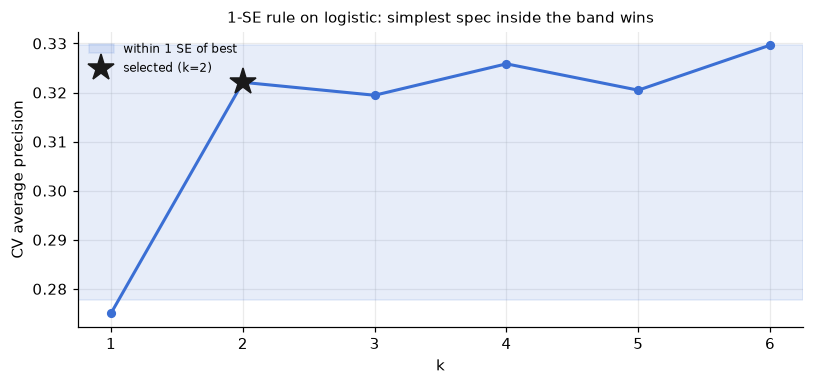

In [7]:
sel = result.selected
gb = lb.query("model == @best_model").sort_values("k")
best = gb["cv_average_precision_mean"].max()
se = gb.loc[gb["cv_average_precision_mean"].idxmax(), "cv_average_precision_se"]

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.axhspan(best - se, best, color=C[best_model], alpha=0.12, label="within 1 SE of best")
ax.plot(gb["k"], gb["cv_average_precision_mean"], color=C[best_model], marker="o", ms=5, lw=2)
ax.plot(sel["k"], sel["cv_average_precision_mean"], marker="*", ms=18, color="#1a1a1a",
        ls="none", label=f"selected (k={sel['k']})")
ax.set_xlabel("k"); ax.set_ylabel("CV average precision")
ax.set_title(f"1-SE rule on {best_model}: simplest spec inside the band wins", fontsize=10)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
print(f"selected : {sel['model']}  k={sel['k']}  ({sel['rule']})")
print(f"variables: {', '.join(sel['features'])}")
print(f"cost of parsimony vs unconstrained best: {sel['cost_of_parsimony']:.4f} AP, "
      f"saving {sel['unconstrained_best']['k'] - sel['k']} variables")

## Step 7 — holdout confirmation: the honest number

Everything above used only the 75% training partition. The selected spec is now refit and
scored **once** on the untouched 25% holdout — this is the number to quote, because no
part of the selection ever saw these rows. Two readings:

- **CV vs holdout:** if holdout lands near the CV estimate, the process didn't overfit its
  own search. A big shortfall means the leaderboard flattered itself.
- **Decile lift:** operational reading — how concentrated is fraud in the top score bands?
- **Slices:** the same holdout broken down by segment. A strong global AP can hide a big
  flag-rate disparity in one segment — the first thing a fairness/model-risk review asks.

CV estimate 0.3221  →  holdout 0.3234   (roc_auc 0.708, ks 0.306)
max flag-rate disparity across slice columns: 3.101 x


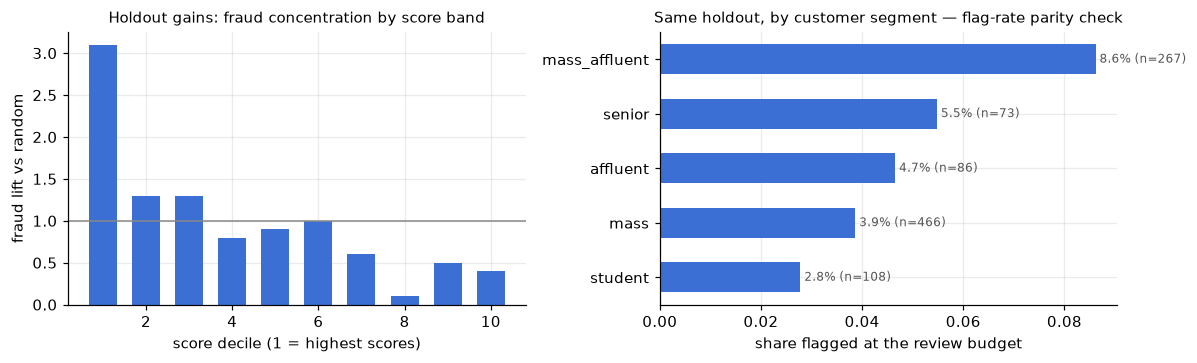

In [8]:
hm = result.holdout_metrics
print(f"CV estimate {sel['cv_average_precision_mean']:.4f}  →  holdout {hm['average_precision']:.4f}"
      f"   (roc_auc {hm['roc_auc']:.3f}, ks {hm['ks_statistic']:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
d = result.holdout_deciles
axes[0].bar(d["band"], d["lift"], color=C[best_model], width=0.65)
axes[0].axhline(1, color="#888", lw=1)
axes[0].set_xlabel("score decile (1 = highest scores)"); axes[0].set_ylabel("fraud lift vs random")
axes[0].set_title("Holdout gains: fraud concentration by score band", fontsize=10)

s = result.holdout_slices.query("slice_column == 'customer_segment'").sort_values("flag_rate_at_top_pct")
axes[1].barh(s["level"], s["flag_rate_at_top_pct"], color=C[best_model], height=0.55)
for y, (v, n) in enumerate(zip(s["flag_rate_at_top_pct"], s["n"])):
    axes[1].text(v, y, f" {v:.1%} (n={n})", va="center", fontsize=8, color="#555")
axes[1].set_xlabel("share flagged at the review budget")
axes[1].set_title("Same holdout, by customer segment — flag-rate parity check", fontsize=10)
plt.tight_layout()
print("max flag-rate disparity across slice columns:",
      result.report.get("holdout_slices")["max_flag_rate_disparity"], "x")

## Step 8 — what leaves the harness

The harness's only durable output is the winning **specification** — a variable list plus a
model — already refit as `result.fitted_model`. Wrapped in `ProductionScorer`, every scored
row carries a probability *and* a data-quality verdict: rows relying on out-of-support
input are routed to manual review, never auto-actioned.

In [9]:
scorer = ProductionScorer(result.fitted_model, threshold=0.5)
fresh = generate_disputes(n=400, seed=99).drop(columns=["dispute_id", "is_fraudulent_dispute"])
scored, report = scorer.score(fresh)
print("batch verdict:", report["verdict"])
scored[["fraud_probability", "data_quality", "decision", "action"]].head(5)

batch verdict: ok


,fraud_probability,data_quality,decision,action
0,0.299499,ok,pass,auto_action
1,0.509389,ok,flag_fraud,manual_review
2,0.756600,ok,flag_fraud,manual_review
3,0.281551,ok,pass,auto_action
4,0.498519,ok,pass,auto_action


## Recap — how each step constrains the next

1. **Config** defines the search space; nothing downstream adds to it.
2. **Ordering (per fold)** decides *which* variable subsets exist — the grid can't score a
   subset the ranking never proposed; stability tells you how trustworthy those subsets are.
3. **Leaderboard** measures every (model, k) honestly; its plateau *suggests* where to stop.
4. **Marginal gains** turn the plateau into per-variable evidence.
5. **1-SE selection** converts that evidence into a single parsimonious spec.
6. **Holdout** is the only number untouched by the search — quote it, and check its slices.

Full-scale run: `python -m dmf.research.cli train --config ../configs/dispute_fraud.yaml`.
Compare alternative configs honestly: `python -m dmf.research.cli sweep --configs a.yaml b.yaml`.
All tables shown here are also written as CSVs under `artifacts_demo/walkthrough/`.